# Credit Card Fraud Detection - Exploratory Data Analysis

## Dataset Overview

This notebook explores the credit card transaction dataset before model development. The analysis focuses on dataset structure, missing values, class imbalance, transaction amounts, and transaction timing.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [14]:
Path.cwd()

PosixPath('/Users/owencollett/Desktop/fraud-detection/notebooks')

In [15]:
data_path = Path("../data/creditcard.csv")

df = pd.read_csv(data_path)

In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
print("Number of transactions:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of transactions: 284807
Number of columns: 31


In [18]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [19]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [21]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [24]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## Summary Statistics

In [25]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [26]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [27]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [28]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [29]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [30]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.25
Name: Amount, dtype: float64

## Data Visualizations

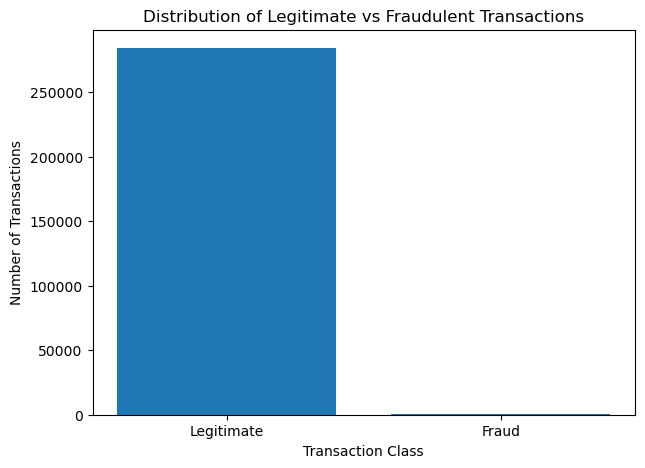

In [31]:
class_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(["Legitimate", "Fraud"], class_counts.values)

plt.title("Distribution of Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

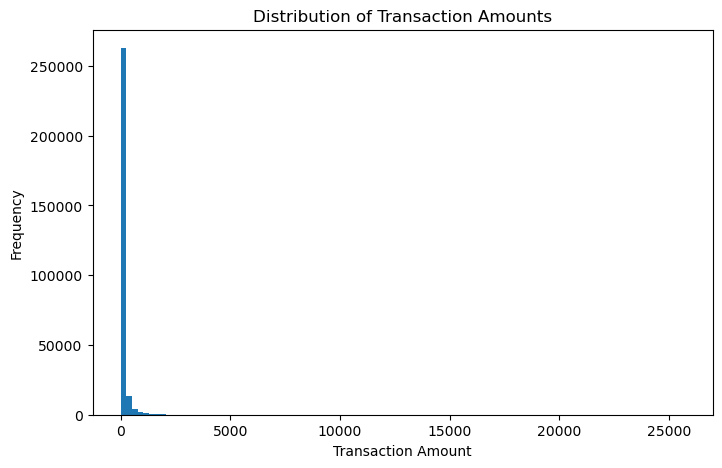

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df["Amount"], bins=100)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [33]:
amount_99 = df["Amount"].quantile(0.99)

amount_99

np.float64(1017.9700000000012)

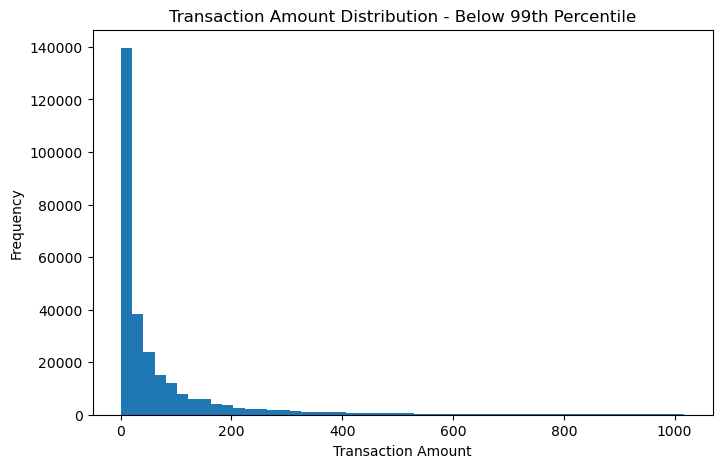

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Amount"] <= amount_99]["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution - Below 99th Percentile")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

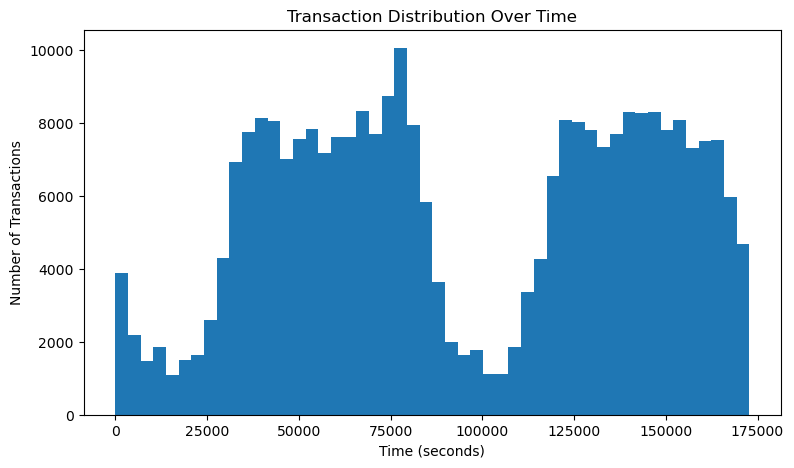

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")

plt.show()

## Duplicate Analysis

In [36]:
df.duplicated().sum()

np.int64(1081)

## Data Dictionary

The dataset contains 284,807 credit card transactions and 31 columns. Each row represents one transaction.

| Column | Description | Data Type |
|---|---|---|
| Time | Elapsed time associated with the transaction | float |
| V1–V28 | Anonymized transformed numerical features | float |
| Amount | Transaction amount | float |
| Class | Target variable: 0 = legitimate, 1 = fraudulent | integer |

## Key Dataset Findings

- The dataset contains 284,807 transactions and 31 columns.
- There are no missing values in the dataset.
- There are 284,315 legitimate transactions and 492 fraudulent transactions.
- Fraud represents approximately 0.173% of all transactions.
- The target variable is therefore extremely imbalanced.
- Transaction amounts are right-skewed, with a relatively small number of very large transactions.
- The Time feature shows that transaction activity is not distributed evenly across the observed period.

In [37]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_count / len(df) * 100)

Duplicate rows: 1081
Duplicate percentage: 0.379555277784605


- The dataset contains 1081 exact duplicate rows. These will be investigated during the data-validation and preprocessing phase before deciding whether they should be removed.

## Dataset Limitations and Anonymized Features

The features V1 through V28 are anonymized numerical features, so their original real-world meanings are not available in this dataset. This protects sensitive transaction information but limits how directly the model's behavior can be interpreted in business terms.

Because the original meanings of these variables are unknown, domain-specific feature engineering using V1–V28 is limited. Any relationship between these features and fraud should therefore be interpreted as a statistical relationship rather than a known causal relationship.

The dataset also provides limited transaction context. Information such as merchant identity, geographic location, cardholder history, device information, and transaction category is not directly available. A real fraud-detection system would likely use substantially more contextual information.

### What We Know

- V1–V28 are numerical features.
- They have already undergone transformation/anonymization.
- They may contain useful statistical signals for distinguishing fraudulent and legitimate transactions.
- They can be used as model inputs.

### What We Do Not Know

- The original business variable represented by each feature.
- The units of the original variables.
- The exact business interpretation of positive or negative values.
- Whether a relationship between one of these features and fraud has a causal explanation.

## Phase 1 Conclusion

The exploratory analysis shows that this is a highly imbalanced binary classification problem. Fraudulent transactions account for only about 0.173% of the dataset, meaning that accuracy alone will not be an appropriate measure of model quality.

The dataset contains no missing values, but transaction amounts are highly skewed and the anonymized features limit direct business interpretation. Exact duplicate rows should also be investigated before model training.

Based on these findings, the next phase should focus on building a reproducible data-validation and preprocessing pipeline. This should include validation of expected columns and data types, handling of duplicates if appropriate, reproducible train/validation/test splitting, and consistent preprocessing that can later be reused during model inference.

## Phase 2: Reproducible Data Pipeline

The dataset is now loaded and validated through reusable Python modules.
This separates repeatable data-processing logic from exploratory notebook code.

In [38]:
from pathlib import Path
import sys

# Find the project root whether this notebook is in the root
# folder or the notebooks folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/owencollett/Desktop/fraud-detection')

In [39]:
from src.data_loader import load_transactions

DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"

df, validation_report = load_transactions(DATA_PATH)

validation_report

{'rows': 284807,
 'columns': 31,
 'fraud_count': 492,
 'legitimate_count': 284315,
 'fraud_rate': np.float64(0.001727485630620034),
 'duplicate_rows': 1081}

In [40]:
from src.validation import validate_transactions

malformed_df = df.drop(columns=["Amount"])

try:
    validate_transactions(malformed_df)
except ValueError as error:
    print(error)

Dataset validation failed:
- Missing columns: ['Amount']


### Deterministic Stratified Data Splitting

The validated dataset is divided into training, validation, and test sets.

- The training set is used to fit models.
- The validation set is used to compare models and tune hyperparameters.
- The test set is reserved for final evaluation.
- Stratification preserves the rare fraud class across all three sets.
- A fixed random state makes the split reproducible.

In [41]:
from src.data_splitter import split_transactions

(
    X_train,
    X_validation,
    X_test,
    y_train,
    y_validation,
    y_test,
) = split_transactions(df)

In [42]:
split_summary = {
    "Training": {
        "rows": len(X_train),
        "percentage": len(X_train) / len(df),
    },
    "Validation": {
        "rows": len(X_validation),
        "percentage": len(X_validation) / len(df),
    },
    "Test": {
        "rows": len(X_test),
        "percentage": len(X_test) / len(df),
    },
}

split_summary

{'Training': {'rows': 199364, 'percentage': 0.6999968399653098},
 'Validation': {'rows': 42721, 'percentage': 0.14999982444251722},
 'Test': {'rows': 42722, 'percentage': 0.15000333559217294}}

In [43]:
import pandas as pd

class_distribution = pd.DataFrame({
    "Split": ["Full Dataset", "Training", "Validation", "Test"],
    "Rows": [
        len(df),
        len(y_train),
        len(y_validation),
        len(y_test),
    ],
    "Fraud Cases": [
        int(df["Class"].sum()),
        int(y_train.sum()),
        int(y_validation.sum()),
        int(y_test.sum()),
    ],
    "Fraud Rate": [
        df["Class"].mean(),
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
})

class_distribution

,Split,Rows,Fraud Cases,Fraud Rate
0,Full Dataset,284807,492,0.001727
1,Training,199364,344,0.001725
2,Validation,42721,74,0.001732
3,Test,42722,74,0.001732


In [44]:
train_indices = set(X_train.index)
validation_indices = set(X_validation.index)
test_indices = set(X_test.index)

print(
    "Training/validation overlap:",
    len(train_indices.intersection(validation_indices)),
)

print(
    "Training/test overlap:",
    len(train_indices.intersection(test_indices)),
)

print(
    "Validation/test overlap:",
    len(validation_indices.intersection(test_indices)),
)

Training/validation overlap: 0
Training/test overlap: 0
Validation/test overlap: 0


In [45]:
(
    X_train_second,
    X_validation_second,
    X_test_second,
    y_train_second,
    y_validation_second,
    y_test_second,
) = split_transactions(df)

In [46]:
print(
    "Training split reproduced:",
    X_train.index.equals(X_train_second.index),
)

print(
    "Validation split reproduced:",
    X_validation.index.equals(
        X_validation_second.index
    ),
)

print(
    "Test split reproduced:",
    X_test.index.equals(X_test_second.index),
)

Training split reproduced: True
Validation split reproduced: True
Test split reproduced: True


### Preprocessing Pipeline

`Time` and `Amount` are standardized because their scales differ substantially
from the PCA-transformed variables. `V1` through `V28` are passed through without
additional scaling.

The preprocessing pipeline is fitted only on the training data. This prevents
information from the validation and test sets from leaking into model training.

In [47]:
from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor()

X_train_array = preprocessor.fit_transform(X_train)

X_validation_array = preprocessor.transform(
    X_validation
)

X_test_array = preprocessor.transform(X_test)

In [48]:
import pandas as pd

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_processed = pd.DataFrame(
    X_train_array,
    columns=processed_feature_names,
    index=X_train.index,
)

X_validation_processed = pd.DataFrame(
    X_validation_array,
    columns=processed_feature_names,
    index=X_validation.index,
)

X_test_processed = pd.DataFrame(
    X_test_array,
    columns=processed_feature_names,
    index=X_test.index,
)

In [49]:
X_train_processed.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
249927,1.257992,-0.321082,-0.012102,0.707332,0.163334,-0.756498,0.590999,-0.653429,0.844608,-0.001672,...,0.329703,-0.038329,-0.231385,-0.572415,0.042660,-0.360882,-0.494703,0.142657,0.235922,0.083758
214082,0.939713,0.243475,1.776151,-0.184642,-2.204096,1.191668,0.614461,-1.016525,0.919254,-0.387465,...,-0.016297,-0.030437,0.281190,0.530070,-0.232262,-0.342096,0.492355,-0.427682,-0.075228,-0.056755
106005,-0.528960,4.797594,-1.083391,-4.440527,-1.399530,0.469764,-2.076458,-0.766137,1.601441,-0.709176,...,-1.087435,2.189260,0.346463,-1.432833,-1.097063,0.505926,-0.140185,0.870190,-0.316982,0.227833
58619,-0.977583,-0.331514,-0.518847,1.025087,-0.614624,-0.780959,2.474666,3.335055,0.046111,0.794249,...,0.929925,0.225957,-0.193099,-0.708348,0.145672,0.944217,-0.788017,0.039995,0.010804,0.254309
191638,0.725456,-0.331514,-0.640421,0.212171,0.283341,-1.786916,2.616127,4.024863,-0.198897,0.937087,...,-0.458141,0.154309,0.167939,0.759218,-0.321412,0.767971,-0.084221,0.612936,0.074029,-0.033344


In [50]:
print(
    "Training shape:",
    X_train_processed.shape
)

print(
    "Validation shape:",
    X_validation_processed.shape
)

print(
    "Test shape:",
    X_test_processed.shape
)

Training shape: (199364, 30)
Validation shape: (42721, 30)
Test shape: (42722, 30)


In [51]:
X_train_processed[
    ["Time", "Amount"]
].agg(["mean", "std"]).round(4)

,Time,Amount
mean,-0.0,0.0
std,1.0,1.0


In [52]:
import numpy as np

print(
    "V1 unchanged:",
    np.allclose(
        X_train_processed["V1"],
        X_train["V1"],
    ),
)

print(
    "V28 unchanged:",
    np.allclose(
        X_train_processed["V28"],
        X_train["V28"],
    ),
)

V1 unchanged: True
V28 unchanged: True


In [53]:
from joblib import dump

MODEL_DIRECTORY = PROJECT_ROOT / "models"
MODEL_DIRECTORY.mkdir(exist_ok=True)

PREPROCESSOR_PATH = (
    MODEL_DIRECTORY / "preprocessor.joblib"
)

dump(preprocessor, PREPROCESSOR_PATH)

print(f"Preprocessor saved to: {PREPROCESSOR_PATH}")

Preprocessor saved to: /Users/owencollett/Desktop/fraud-detection/models/preprocessor.joblib


In [54]:
from joblib import load

loaded_preprocessor = load(PREPROCESSOR_PATH)

original_result = preprocessor.transform(
    X_test.iloc[:10]
)

loaded_result = loaded_preprocessor.transform(
    X_test.iloc[:10]
)

print(
    "Saved pipeline produces identical results:",
    np.allclose(original_result, loaded_result),
)

Saved pipeline produces identical results: True


In [55]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = (
    PROJECT_ROOT / "data" / "creditcard.csv"
)

PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "models"
    / "preprocessor.joblib"
)

### Complete Reproducible Data Pipeline

The complete data-preparation process is executed through one reusable function.
This function loads and validates the raw data, creates deterministic stratified
splits, fits preprocessing using only training data, transforms every split, and
saves the fitted preprocessor.

In [56]:
from src.pipeline import prepare_data

prepared_data = prepare_data(
    data_path=DATA_PATH,
    preprocessor_path=PREPROCESSOR_PATH,
    random_state=42,
)

In [57]:
X_train = prepared_data["X_train"]
X_validation = prepared_data["X_validation"]
X_test = prepared_data["X_test"]

y_train = prepared_data["y_train"]
y_validation = prepared_data["y_validation"]
y_test = prepared_data["y_test"]

preprocessor = prepared_data["preprocessor"]
validation_report = prepared_data[
    "validation_report"
]

In [58]:
validation_report

{'rows': 284807,
 'columns': 31,
 'fraud_count': 492,
 'legitimate_count': 284315,
 'fraud_rate': np.float64(0.001727485630620034),
 'duplicate_rows': 1081}

In [59]:
import pandas as pd

In [60]:
pipeline_summary = pd.DataFrame({
    "Split": [
        "Training",
        "Validation",
        "Test",
    ],
    "Rows": [
        len(X_train),
        len(X_validation),
        len(X_test),
    ],
    "Features": [
        X_train.shape[1],
        X_validation.shape[1],
        X_test.shape[1],
    ],
    "Fraud Cases": [
        int(y_train.sum()),
        int(y_validation.sum()),
        int(y_test.sum()),
    ],
    "Fraud Rate": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
})

pipeline_summary

,Split,Rows,Features,Fraud Cases,Fraud Rate
0,Training,199364,30,344,0.001725
1,Validation,42721,30,74,0.001732
2,Test,42722,30,74,0.001732


In [61]:
second_run = prepare_data(
    data_path=DATA_PATH,
    random_state=42,
)

In [62]:
import numpy as np

print(
    "Same training rows:",
    X_train.index.equals(
        second_run["X_train"].index
    ),
)

print(
    "Same validation rows:",
    X_validation.index.equals(
        second_run["X_validation"].index
    ),
)

print(
    "Same test rows:",
    X_test.index.equals(
        second_run["X_test"].index
    ),
)

print(
    "Same processed values:",
    np.allclose(
        X_train.iloc[:100],
        second_run["X_train"].iloc[:100],
    ),
)

Same training rows: True
Same validation rows: True
Same test rows: True
Same processed values: True


In [63]:
del second_run

In [64]:
print(
    "Preprocessor exists:",
    PREPROCESSOR_PATH.exists(),
)

print(
    "Saved location:",
    PREPROCESSOR_PATH,
)

Preprocessor exists: True
Saved location: /Users/owencollett/Desktop/fraud-detection/models/preprocessor.joblib


## Phase 2 Conclusion

During Phase 2, I converted the initial exploratory workflow into a
reproducible data pipeline. Raw transaction data is now loaded and validated
through reusable Python modules. The validation process checks the expected
schema, numeric data types, missing values, invalid class labels, infinite
values, and invalid ranges.

I created deterministic training, validation, and test sets using stratified
sampling. The training set contains 70% of the transactions, while the
validation and test sets each contain 15%. Stratification preserves the rare
fraud rate across all three datasets, and the fixed random state ensures that
the same transactions are assigned to each split every time the pipeline runs.

The preprocessing pipeline standardizes Time and Amount while leaving V1
through V28 unchanged. The scaler is fitted only on the training set and is
then applied identically to the validation and test sets. This prevents data
leakage and makes the same preprocessing available for future inference.

Finally, I combined loading, validation, splitting, and preprocessing into one
reusable function and added automated tests. The tests confirm that malformed
data fails clearly and that repeated pipeline runs produce identical results.
The processed datasets are now ready for supervised model development.